# Distance-decay / Contact probabiliity curve

### Plot the smoothed P(s) curve and its derivative

https://cooltools.readthedocs.io/en/latest/notebooks/contacts_vs_distance.html

In [57]:
import hicstraw
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.ndimage import gaussian_filter1d


def log_smooth_pure_numpy(xs, ys, sigma_log10=0.1):
    """Smooths curves using a Gaussian kernel across a regularly sampled log-space,

    matching the mathematical logic of cooltools `log_smooth`.
    """
    xs = np.asarray(xs)
    ys = np.asarray(ys)

    # Establish an evenly spaced grid in log10 space for convolution
    log_x = np.log10(xs)
    num_points = len(xs)
    log_x_uniform = np.linspace(log_x.min(), log_x.max(), num_points)

    # Map the metric data onto the uniform log grid
    ys_uniform = np.interp(log_x_uniform, log_x, ys)

    # Compute step resolution in log10 units to calculate pixel-width sigma
    delta_log_x = (log_x_uniform.max() - log_x_uniform.min()) / (num_points - 1)
    sigma_pixels = sigma_log10 / delta_log_x

    # Convolve with a 1D Gaussian kernel using 'nearest' for old scipy compatibility
    ys_smoothed_uniform = gaussian_filter1d(
        ys_uniform, sigma=sigma_pixels, mode="nearest"
    )

    # Interpolate back to original input coordinates
    ys_smoothed = np.interp(log_x, log_x_uniform, ys_smoothed_uniform)
    return ys_smoothed


def compute_hic_expected_cis(
    hic_file,
    chrom="1",
    resolution=5000,
    norm="NONE",
    norm_max_dist=100_000_000,
):
    """Computes distance-dependent expected interactions (P(s)) for a .hic file,

    normalizing probabilities based only on distances up to norm_max_dist.
    """
    hic = hicstraw.HiCFile(hic_file)

    chrom_names = [c.name for c in hic.getChromosomes()]
    target_chrom = f"chr{chrom}" if f"chr{chrom}" in chrom_names else chrom
    chrom_len = [c.length for c in hic.getChromosomes() if c.name == target_chrom][0]
    total_bins = chrom_len // resolution + 1

    matrix_object = hic.getMatrixZoomData(
        target_chrom, target_chrom, "observed", norm, "BP", resolution
    )
    matrix = matrix_object.getRecords(0, chrom_len, 0, chrom_len)

    df = pd.DataFrame(
        [[r.binX, r.binY, r.counts] for r in matrix],
        columns=["bin1_id", "bin2_id", "count"],
    )

    df["diag"] = np.abs(df["bin1_id"] - df["bin2_id"]) // resolution
    expected_df = df.groupby("diag")["count"].sum().reset_index()

    expected_df["n_valid"] = total_bins - expected_df["diag"]
    expected_df = expected_df[expected_df["n_valid"] > 0]

    expected_df["balanced.avg"] = expected_df["count"] / expected_df["n_valid"]
    expected_df["s_bp"] = expected_df["diag"] * resolution
    expected_df = expected_df[expected_df["diag"] > 0]

    expected_df = expected_df.sort_values("s_bp").reset_index(drop=True)
    expected_df["balanced.avg.smoothed"] = log_smooth_pure_numpy(
        expected_df["s_bp"].values,
        expected_df["balanced.avg"].values,
        sigma_log10=0.1,
    )

    # Filter out noisy, long-range diagonals before computing the normalization baseline
    valid_range_df = expected_df[expected_df["s_bp"] <= norm_max_dist]
    total_sum = valid_range_df["balanced.avg.smoothed"].sum()

    # Apply the truncated normalization factor across all points
    expected_df["probability"] = expected_df["balanced.avg.smoothed"] / total_sum

    return expected_df


# 1. Gather normalized structures for all paths
conditions = [
    {"name": "Control", "hic": ctrl},
    {"name": "Treatment 1", "hic": t1},
    {"name": "Treatment 2", "hic": t2},
]

maps = []
for cond in conditions:
    res_df = compute_hic_expected_cis(
        cond["hic"], chrom="1", resolution=5000, norm="VC_SQRT"
    )
    maps.append({"name": cond["name"], "data": res_df})

In [62]:
plt.rcParams['pdf.fonttype'] = 42

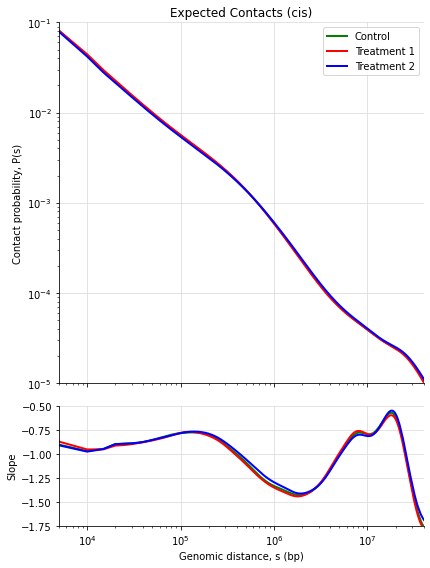

In [63]:
# 2. Plotting execution using log-smoothed values (no downstream binning needed)
colors = {"Control": "green", "Treatment 1": "red", "Treatment 2": "blue"}

fig, axs = plt.subplots(
    figsize=(6, 8), nrows=2, gridspec_kw={"height_ratios": [6, 2]}, sharex=True
)

ax_top = axs[0]
ax_bottom = axs[1]

for item in maps:
    name = item["name"]
    df_ps = item["data"]

    if not df_ps.empty:
        # Top Plot: Log-log P(s) curve using Gaussian smoothed values
        ax_top.loglog(
            df_ps["s_bp"],
            df_ps["probability"],
            linewidth=2,
            color=colors[name],
            label=name,
        )

        # Calculate derivative directly from the smoothly convolved vectors
        log_x = np.log(df_ps["s_bp"].values)
        log_y = np.log(df_ps["probability"].values)
        der = np.gradient(log_y, log_x)

        # Bottom Plot: Semilogx slope derivative curve
        ax_bottom.semilogx(
            df_ps["s_bp"],
            der,
            linewidth=2,
            color=colors[name],
        )

# Styling Top Axis
ax_top.set_ylabel("Contact probability, P(s)")
ax_top.set_title("Expected Contacts (cis)")
ax_top.set_ylim(10**-5, 10**-1)
ax_top.grid(True, which="major", color="#dddddd", linestyle="-")
ax_top.legend(frameon=True)
ax_top.spines["top"].set_visible(False)
ax_top.spines["right"].set_visible(False)
ax_top.set_xlim(5000, 40_000_000)


# Styling Bottom Axis
ax_bottom.set_xlabel("Genomic distance, s (bp)")
ax_bottom.set_ylabel("Slope")
ax_bottom.set_xlim(5000, 40_000_000)
ax_bottom.set_ylim(-1.75, -0.5)
ax_bottom.grid(True, which="major", color="#dddddd", linestyle="-")
ax_bottom.spines["top"].set_visible(False)
ax_bottom.spines["right"].set_visible(False)

plt.tight_layout()
plt.savefig('Ps_contacts_plot_slope.pdf')